# Return convergence — training and in-training eval return, per reward variant

Draws **two figures per reward variant** — the training return
`ray/tune/env_runners/episode_return_mean` and the in-training evaluation return
`ray/tune/evaluation/env_runners/episode_return_mean` — each overlaying the **PPO** and **SAC**
runs of the multi-objective `sta_lin_battery_EV` trial (linear battery plus V2G-enabled EV
charger, one static infra config), so the per-group results of
[`sps_eval_catplot_cmp.ipynb`](sps_eval_catplot_cmp.ipynb) can be read against how far each run
converged and against how far its training return had separated from its eval return. Within a
variant, the PPO and SAC runs share the snapshot code and the trial YAML apart from `algorithm`
(and the base PPO run's `trial_name`); the variants differ only in the reward stack:

| Variant | Reward stack — every variant carries `EconomicRewardV0` + `OperatorEnergyControlRewardV0` (weight 1.0) |
|---|---|
| base | + `EVChargingSessionReward`, `charge_progress_scale = 0.5` |
| v2 | + `EVChargingSessionReward`, `charge_progress_scale = 10` |
| old rewards | + `EVChargingRewardV0` (`diff_threshold = 0.02`, `soc_diff_multiplier = 5.0`) in place of the session reward |
| regulator rewards | the `v2` stack + `BESRegulatorReward` + `EVRegulatorReward` (`penalty = -1.0` each) |

> **Why one figure pair per reward variant, not per algorithm.** The return sums the stack's
> rewards, so every variant's return lives on its own scale: the two regulators alone pay -1 on
> each step whose battery or EV action the hardware clips or overrides — down to -576 over a
> 288-step episode — and the `old rewards` returns start out thousands below zero. A figure
> holding several variants would squash the `base` / `v2` curves into a flat band. PPO and SAC of
> one variant score under the same stack, so they share a figure — the comparability grouping of
> the catplot notebook.

The `_eval_ch` snapshots of `base` and `v2` are not listed: they re-evaluate the same checkpoints
on the training EV profiles and hold a byte-identical copy of their twin's training event file,
so their curves would coincide with the twin's.

> **What the eval curve measures.** The in-training eval runs 10 episodes every 10 training
> iterations (`training_params.common.evaluation`: `interval` / `duration`) — every 120 training
> episodes for PPO, every 20 for SAC (see the x-axis note). Its env runners carry `eval_mode=True`
> and therefore draw from the trial's **eval data schedule** (`eval_data_combinator`, picked in
> `adv_building_gym/ray/env_creator.py` of the snapshot code), which shares none of the training
> pool's EV-usage profiles (`ev_eval_0…3` vs `ev_0…5`), setpoint profiles (`inside_temp_eval_0…3`
> vs `inside_temp_0…2`), household profiles (2019 vs 2020 SFH) or weather / price years (2025-26
> vs 2024); only the five operator signals are common to both. Since this trial's held-out axis
> is the data itself rather than an infra config (as in the GEN notebooks), the eval curve does
> run on held-out episodes. The September standalone evals (`runs/eval_20260906_*`) draw from the
> same held-out pool minus six `_neg` synthesised household profiles: every snapshot's
> `snapshot.zip` still lists them in `configs/schedules/data/eval.yaml`, while the extracted
> `code/` copy those evals read comments them out (edited 2026-09-06, after all training).
> Between two eval rounds the result carries the last round's value forward, so from iteration 10
> on every iteration has an eval point but only every 10th is new — the raw eval line is a
> staircase.

For every snapshot the main RLlib TBX event file written by `tuner.fit()` under
`runs/train_*/models/**/events.out.tfevents.*` is parsed (the `ep_metrics/eval_trajectories/`
sub-runs live outside `models/` and are not matched by that glob) and three scalars are
extracted in a single pass: the two return curves above and the lifetime env-step counter
`ray/tune/env_runners/num_env_steps_sampled_lifetime`.

> **x-axis.** In these logs the TBX step already *is* the env-step counter (identical on every
> logged row). The counter is nevertheless read explicitly and used as the x-axis — as in the
> battery-capacity and battery-power notebooks — so the plot does not depend on which step axis a
> log was written with. One iteration is a different amount of experience per algorithm: a PPO
> iteration advances the counter by 3456 (12 × 288; the first by 6912) over 583 iterations — the
> YAML's `ppo.episodes_per_iteration: 10` is raised to 12, the next multiple of the 4 env runners
> (`adv_building_gym/ray/training/resource_setup.py` of the snapshot code; every PPO training log
> warns `raising episodes/iteration 10 -> 12`) — and a SAC iteration by 576 (4 env runners × the
> 144-step `sac.rollout_length` fragment; twice that on 12 iterations, 11 for
> `regulator rewards`) over 3488 iterations (3489 for `regulator rewards`). Both nevertheless
> cover essentially the same experience: PPO 2 018 304 steps / 7008 episodes, SAC 2 016 000 /
> 7000. The PPO runs were trained on 2026-07-27, the SAC runs on 2026-07-21 / 22.
> With `X_AXIS = "episodes"` the counter is shown as `env_steps / EPISODE_LENGTH` with a major
> tick every `X_TICK_EPISODES` (1000) episodes; `X_AXIS = "env_steps"` relabels the same data in
> millions of env steps, ticked every `X_TICK_ENV_STEPS` (250 000).

Parsing an event file is slow (the SAC logs are ~70 MB), so the extracted curves are cached as
small CSVs under `.tb_return_cache/` next to this notebook; delete that folder to force a
re-parse.

**Main input:** set `SOURCES` in the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# The snapshots whose return curves are plotted. Entries are grouped by "variant": every
# distinct variant gets its own pair of figures (training return, then in-training eval
# return), overlaying that variant's algorithms. The entries use the member format of the
# catplot notebook's SNAPSHOT_GROUPS. Keys per entry:
#   path     snapshot dir (absolute, or relative to the repo root)
#   algo     algorithm; shown in the legend, coloured via ALGO_COLORS
#   variant  reward variant — one figure pair per distinct value, in first-seen order

# The 12 sta_lin_battery_EV snapshots, for reference. The four _eval_ch snapshots are left
# out: each holds a byte-identical copy of its twin's training event file.
#   20260721_093047_sta_lin_battery_EV_ppo              base            PPO
#   20260721_093047_sta_lin_battery_EV_ppo_eval_ch      base            PPO, eval on training EVs
#   20260721_101901_sta_lin_battery_EV_ppo_v2           v2              PPO
#   20260721_101901_sta_lin_battery_EV_ppo_v2_eval_ch   v2              PPO, eval on training EVs
#   20260721_102122_sta_lin_battery_EV_mo_ppo_old       old rewards     PPO
#   20260721_102226_sta_lin_battery_EV_ppo              regulator       PPO   <- same suffix as base, different run
#   20260721_103047_sta_lin_battery_EV_sac              base            SAC
#   20260721_103047_sta_lin_battery_EV_sac_eval_ch      base            SAC, eval on training EVs
#   20260721_111901_sta_lin_battery_EV_sac_v2           v2              SAC
#   20260721_111901_sta_lin_battery_EV_sac_v2_eval_ch   v2              SAC, eval on training EVs
#   20260722_123922_sta_lin_battery_EV_mo_sac_old       old rewards     SAC
#   20260722_134026_sta_lin_battery_EV_sac              regulator       SAC

SOURCES = [
    # --- base ------------------------------------------------------------------------
    {"path": "snapshots/20260721_093047_sta_lin_battery_EV_ppo", "algo": "PPO", "variant": "base"},
    {"path": "snapshots/20260721_103047_sta_lin_battery_EV_sac", "algo": "SAC", "variant": "base"},
    # --- v2 --------------------------------------------------------------------------
    {"path": "snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2", "algo": "PPO", "variant": "v2"},
    {"path": "snapshots/20260721_111901_sta_lin_battery_EV_sac_v2", "algo": "SAC", "variant": "v2"},
    # --- old rewards -----------------------------------------------------------------
    {"path": "snapshots/20260721_102122_sta_lin_battery_EV_mo_ppo_old", "algo": "PPO", "variant": "old rewards"},
    {"path": "snapshots/20260722_123922_sta_lin_battery_EV_mo_sac_old", "algo": "SAC", "variant": "old rewards"},
    # --- regulator rewards -----------------------------------------------------------
    {"path": "snapshots/20260721_102226_sta_lin_battery_EV_ppo", "algo": "PPO", "variant": "regulator rewards"},
    {"path": "snapshots/20260722_134026_sta_lin_battery_EV_sac", "algo": "SAC", "variant": "regulator rewards"},
]

# Line colour per algorithm, shared across the variants' figures so all of them read the same
# way — blue and orange of the validated 8-slot palette the 2_base_bat_rbc_vs_rl convergence
# notebooks draw from.
ALGO_COLORS = {
    "PPO": "#2a78d6",   # blue
    "SAC": "#eb6834",   # orange
}

# The two RLlib return scalars, plus the lifetime env-step counter that supplies the
# x-axis. All three are pulled from the same event file in one pass.
TRAIN_METRIC = "ray/tune/env_runners/episode_return_mean"
EVAL_METRIC = "ray/tune/evaluation/env_runners/episode_return_mean"
ENV_STEPS_TAG = "ray/tune/env_runners/num_env_steps_sampled_lifetime"

# The figures drawn per variant: (curve column, y-axis label, filename tag).
FIGURE_KINDS = (
    ("train_return", "Mean training return", "train"),
    ("eval_return", "Mean evaluation return", "eval"),
)

# TensorBoard-style EWMA weight in [0, 1): 0 = raw, higher = smoother. The raw curve is drawn
# faint behind the smoothed one when SHOW_RAW is True.
SMOOTHING = 0.99
SHOW_RAW = True

# x-axis unit: "env_steps" plots millions of environment steps, "episodes" plots
# env_steps / EPISODE_LENGTH. Major ticks land every X_TICK_ENV_STEPS / X_TICK_EPISODES.
X_AXIS = "episodes"
X_TICK_ENV_STEPS = 250_000
X_TICK_EPISODES = 1_000
EPISODE_LENGTH = 288

# Upper x-limit (in env steps) shared by every figure so the pairs line up; None takes the
# largest final env-step count across all loaded sources.
X_MAX_ENV_STEPS: float | None = None

# Return-axis major tick spacing per variant, in return units. Per variant because the
# reward stacks put the returns on different scales; a variant's training and eval figure
# share the spacing.
Y_TICK_UNITS = {
    "base": 20.0,
    "v2": 20.0,
    "old rewards": 500.0,
    "regulator rewards": 50.0,
}

# Grid density: how many sub-intervals each major tick interval is split into by minor
# gridlines (1 = major gridlines only). Minor lines are drawn thinner and fainter.
X_MINOR_DIVISIONS = 2
Y_MINOR_DIVISIONS = 2

In [2]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader
from tensorboard.util import tensor_util

# Bumped whenever the cached CSV's columns change, so a stale cache is re-parsed rather than read.
CACHE_SCHEMA = "v2-tbstep-envsteps-train-eval"


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
CACHE_DIR = NB_DIR / ".tb_return_cache"


# The main RLlib TBX log under models/ (largest event file wins; the per-episode
# eval_trajectories/ sub-runs live elsewhere and are not matched by this glob).
def _training_event_file(snapshot_dir: Path) -> Path:
    candidates = sorted(
        snapshot_dir.glob("runs/train_*/models/**/events.out.tfevents.*"),
        key=lambda path: path.stat().st_size, reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No training TBX event file under {snapshot_dir / 'runs/train_*/models'}")
    return candidates[0]


# Pulls both return curves and the lifetime env-step counter out of an event file in ONE
# pass (walking the file is the slow part), indexed by the TBX step — the env-step counter
# itself for these snapshots, the training iteration for logs written before 2026-07-15; the
# plots only ever use the explicit env_steps column. Tags that log on different steps (eval
# starts at evaluation_interval) simply leave NaNs in their column.
# Cached as a small CSV keyed by the event file's path + size + mtime, so an updated log
# re-parses. The path is resolved first: this tree is reachable both as /home/... and as
# /hkfs/home/..., and an unresolved key would miss the cache when the kernel reports the
# other form (VS Code's __vsc_ipynb_file__ and the cwd disagree here).
def _extract_curves(event_file: Path) -> pd.DataFrame:
    stat = event_file.stat()
    cache_key = hashlib.md5(f"{event_file.resolve()}|{stat.st_size}|{int(stat.st_mtime)}|{CACHE_SCHEMA}".encode()).hexdigest()
    cache_path = CACHE_DIR / f"{cache_key}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    wanted = {ENV_STEPS_TAG: "env_steps", TRAIN_METRIC: "train_return", EVAL_METRIC: "eval_return"}
    columns: dict[str, dict[int, float]] = {name: {} for name in wanted.values()}
    for event in EventFileLoader(str(event_file)).Load():
        for value in event.summary.value:
            column = wanted.get(value.tag)
            if column is None:
                continue
            # RLlib writes scalars in the tensor field; legacy simple_value is the fallback.
            scalar = float(tensor_util.make_ndarray(value.tensor)) if value.HasField("tensor") else value.simple_value
            columns[column][event.step] = scalar

    if not columns["env_steps"]:
        raise ValueError(f"Tag {ENV_STEPS_TAG!r} not found in {event_file} — no x-axis available")
    curve = pd.DataFrame(columns).rename_axis("tb_step").sort_index().reset_index()
    CACHE_DIR.mkdir(exist_ok=True)
    curve.to_csv(cache_path, index=False)
    return curve


# TensorBoard's debiased exponential moving average (the "smoothing" slider).
def _tb_smooth(values, weight: float):
    if weight <= 0.0:
        return list(values)
    smoothed, last, debias_weight = [], 0.0, 0.0
    for value in values:
        last = last * weight + (1.0 - weight) * float(value)
        debias_weight = debias_weight * weight + (1.0 - weight)
        smoothed.append(last / debias_weight)
    return smoothed


VARIANT_ORDER = list(dict.fromkeys(source["variant"] for source in SOURCES))
source_keys = [(source["variant"], source["algo"]) for source in SOURCES]
if len(source_keys) != len(set(source_keys)):
    raise ValueError(f"Every (variant, algo) pair must be unique; got {source_keys}")
uncoloured = sorted({source["algo"] for source in SOURCES} - ALGO_COLORS.keys())
if uncoloured:
    raise KeyError(f"ALGO_COLORS has no entry for {uncoloured}")
unticked = [variant for variant in VARIANT_ORDER if variant not in Y_TICK_UNITS]
if unticked:
    raise KeyError(f"Y_TICK_UNITS has no entry for {unticked}")
print(f"Repo root: {REPO_ROOT}\nCache dir: {CACHE_DIR}\nVariants: {', '.join(VARIANT_ORDER)}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Cache dir: /home/iai/dj0397/AdvBuildingGym/thesis_eval/7_mo_bat_ev/.tb_return_cache
Variants: base, v2, old rewards, regulator rewards


## Output naming

Everything saved here lands next to the notebook as
`<variant>_<kind>_return_<date>_<time>_out_<i>.<file format>` — e.g. `v2_train_return_…` and
`v2_eval_return_…` for the v2 pair, with the variant label made filename-safe
(`regulator rewards` → `regulator_rewards`): one timestamp per notebook run, `out_index`
counting up per saved artefact, so no run overwrites an earlier one.

In [3]:
import re
from datetime import datetime

OUT_DIR = NB_DIR
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def file_tag(label: str) -> str:
    """Filename-safe form of a legend label: lower case, every other run of characters -> '_'."""
    return re.sub(r"[^0-9a-z]+", "_", label.lower()).strip("_")


def next_out_path(prefix: str, file_format: str) -> Path:
    """Next '<prefix>_<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{prefix}_{OUT_RUN_STAMP}_out_{out_index}.{file_format}"

## Load the return curves

Each snapshot's main training event file is located and its three scalars extracted (cached
after the first parse). The table lists, per (variant, algo): how many iterations the run
logged, how much experience that actually was in env steps and episodes, and for each of the
two return curves the number of logged points, the smoothed final value (what the end of the
plotted line shows) and the best raw value. Compare the return columns only within a variant.

In [4]:
curves: dict[tuple[str, str], pd.DataFrame] = {}
summary_rows = []
for source in SOURCES:
    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")
    event_file = _training_event_file(snapshot_dir)
    curve = _extract_curves(event_file)
    curves[(source["variant"], source["algo"])] = curve

    env_steps = curve["env_steps"].dropna()
    final_env_step = int(env_steps.iloc[-1])
    row = {
        "variant": source["variant"],
        "algo": source["algo"],
        # One counter point per Tune result, i.e. per training iteration. The TBX step is the
        # env step for these snapshots, so its maximum is not the iteration count.
        "iterations": len(env_steps),
        "env_steps": final_env_step,
        "episodes": final_env_step // EPISODE_LENGTH,
    }
    for column, _, kind in FIGURE_KINDS:
        series = curve[column].dropna()
        if series.empty:
            raise ValueError(f"No {column!r} points in {event_file}")
        row[f"{kind}_points"] = len(series)
        row[f"{kind}_final_smoothed"] = round(float(_tb_smooth(series.to_numpy(), SMOOTHING)[-1]), 3)
        row[f"{kind}_max_raw"] = round(float(series.max()), 3)
    summary_rows.append(row)
    print(f"{source['variant']:>17} / {source['algo']}: {row['iterations']:>5} iters, {final_env_step:>9,} env steps"
          f"  ->  {event_file.relative_to(REPO_ROOT)}")

summary = pd.DataFrame(summary_rows).set_index(["variant", "algo"])

# Shared upper x-limit (env steps) so every figure spans the same range.
X_MAX = float(X_MAX_ENV_STEPS) if X_MAX_ENV_STEPS is not None else float(summary["env_steps"].max())
print(f"\nShared x-limit: {X_MAX:,.0f} env steps  ({X_MAX / EPISODE_LENGTH:,.0f} episodes)")
summary

             base / PPO:   583 iters, 2,018,304 env steps  ->  snapshots/20260721_093047_sta_lin_battery_EV_ppo/runs/train_20260727_102843/models/sta_lin_battery_EV_ppo/ray/ppo/ppo_seed42_20260727_113157/03701_sta_lin_battery_EV_ppo/events.out.tfevents.1785144766.haicn1702.localdomain
             base / SAC:  3488 iters, 2,016,000 env steps  ->  snapshots/20260721_103047_sta_lin_battery_EV_sac/runs/train_20260721_103048/models/sta_lin_battery_EV/ray/sac/sac_seed42_20260721_103333/dc62d_sta_lin_battery_EV/events.out.tfevents.1784622856.haicn1701.localdomain
               v2 / PPO:   583 iters, 2,018,304 env steps  ->  snapshots/20260721_101901_sta_lin_battery_EV_ppo_v2/runs/train_20260727_102844/models/sta_lin_battery_EV/ray/ppo/ppo_seed42_20260727_113157/03704_sta_lin_battery_EV/events.out.tfevents.1785144766.haicn1702.localdomain
               v2 / SAC:  3488 iters, 2,016,000 env steps  ->  snapshots/20260721_111901_sta_lin_battery_EV_sac_v2/runs/train_20260721_111901/models/sta_li

iterations  env_steps  episodes  train_points  \
variant           algo                                                  
base              PPO          583    2018304      7008           583   
                  SAC         3488    2016000      7000          3487   
v2                PPO          583    2018304      7008           583   
                  SAC         3488    2016000      7000          3487   
old rewards       PPO          583    2018304      7008           583   
                  SAC         3488    2016000      7000          3487   
regulator rewards PPO          583    2018304      7008           583   
                  SAC         3489    2016000      7000          3488   

                        train_final_smoothed  train_max_raw  eval_points  \
variant           algo                                                     
base              PPO                -50.844          6.668          574   
                  SAC                 16.607         52.016         3479   
v2                PPO                -47.254         39.664          574   
                  SAC                 33.221         69.398         3479   
old rewards       PPO              -1258.066        -20.412          574   
                  SAC               -106.645         30.242         3479   
regulator rewards PPO               -198.478        -94.649          574   
                  SAC               -142.912         10.950         3480   

                        eval_final_smoothed  eval_max_raw  
variant           algo                                     
base              PPO               -87.135       -61.998  
                  SAC               -34.141       -21.498  
v2                PPO               -86.927       -44.813  
                  SAC                 2.243        19.998  
old rewards       PPO             -1338.277      -415.027  
                  SAC              -196.174       -56.701  
regulator rewards PPO              -241.633      -214.133  
                  SAC              -224.995      -132.376

## Convergence plots

Two figures per reward variant — training return, then in-training evaluation return — each
overlaying that variant's PPO and SAC runs in their `ALGO_COLORS`, smoothed with TensorBoard's
debiased EWMA (`SMOOTHING = 0.99`); the raw curve is drawn faint behind each smoothed line while
`SHOW_RAW` is set. The EWMA weight applies per logged point, i.e. per iteration, so its effective
span in episodes differs by algorithm (a PPO point is 12 episodes of experience, a SAC point 2) —
the PPO line is smoothed over six times as many episodes, so compare the two by level and trend,
not by the smoothness of their lines.

Both axes are on fixed, readable scales: every figure shares the same x-limit with a major tick
every `X_TICK_EPISODES` = 1000 episodes (every `X_TICK_ENV_STEPS` = 250 000 env steps when
`X_AXIS = "env_steps"`), and the return axis carries a major tick every `Y_TICK_UNITS[variant]`
return units — 20 for `base` and `v2`, 500 for `old rewards`, 50 for `regulator rewards`, the
same for a variant's training and eval figure. `X_MINOR_DIVISIONS` / `Y_MINOR_DIVISIONS` add a
minor gridline halfway between each pair of major ticks — a thinner, fainter grid — so a
variant's training and eval curves can be read off against each other. The figures carry **no
title** (thesis-ready) and are saved as `<variant>_<kind>_return_<date>_<time>_out_<i>.pdf` next
to this notebook.

base — train: saved base_train_return_20260925_134356_out_1.pdf


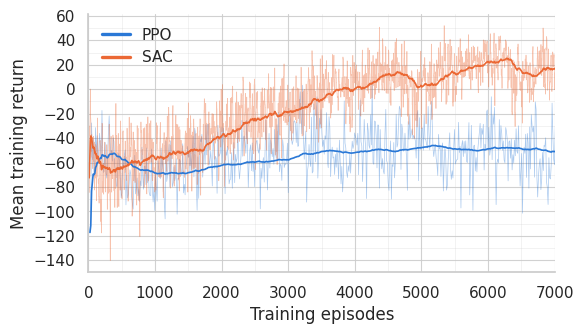

base — eval: saved base_eval_return_20260925_134356_out_2.pdf


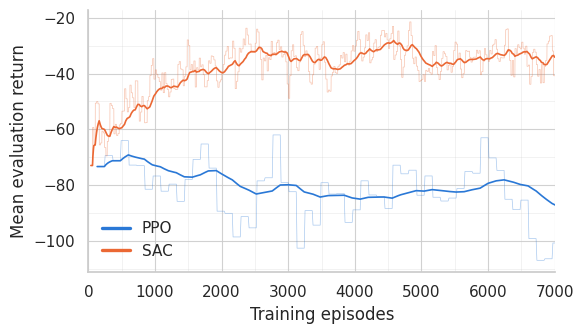

v2 — train: saved v2_train_return_20260925_134356_out_3.pdf


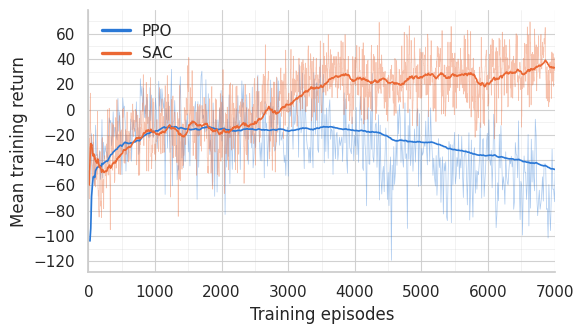

v2 — eval: saved v2_eval_return_20260925_134356_out_4.pdf


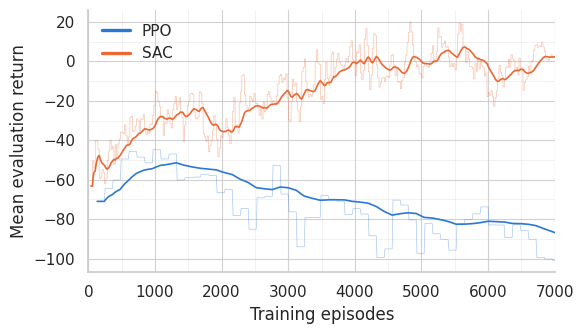

old rewards — train: saved old_rewards_train_return_20260925_134356_out_5.pdf


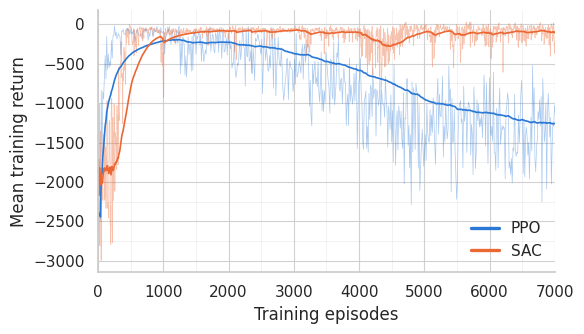

old rewards — eval: saved old_rewards_eval_return_20260925_134356_out_6.pdf


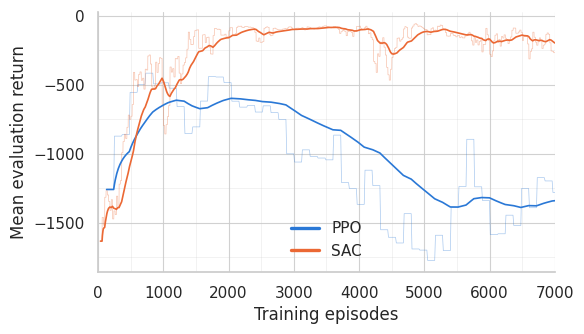

regulator rewards — train: saved regulator_rewards_train_return_20260925_134356_out_7.pdf


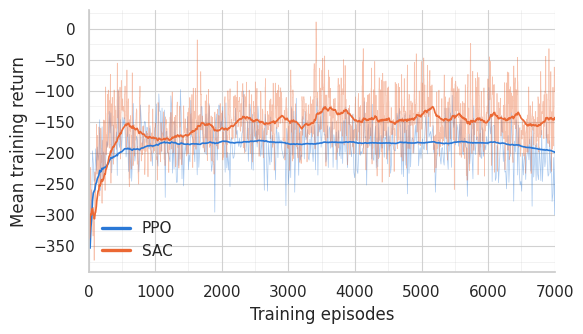

regulator rewards — eval: saved regulator_rewards_eval_return_20260925_134356_out_8.pdf


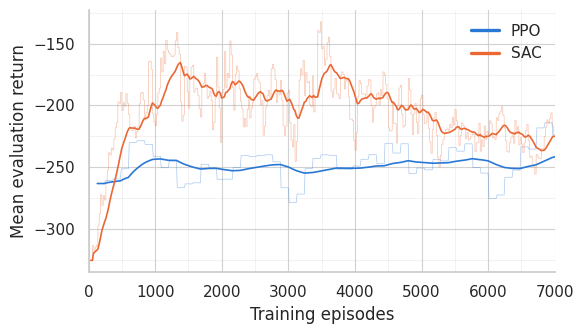

In [5]:
sns.set_theme(style="whitegrid", context="notebook")


# (divisor applied to env_steps, axis label, major-tick spacing, upper limit) for the
# configured X_AXIS. Everything is derived from the run's env-step counter, never from the
# TBX step, so logs indexed by iteration and by env step plot on the same axis.
def _x_axis_spec() -> tuple[float, str, float, float]:
    if X_AXIS == "env_steps":
        return 1e6, "Environment steps (millions)", X_TICK_ENV_STEPS / 1e6, X_MAX / 1e6
    if X_AXIS == "episodes":
        return float(EPISODE_LENGTH), "Training episodes", float(X_TICK_EPISODES), X_MAX / EPISODE_LENGTH
    raise ValueError(f"X_AXIS must be 'env_steps' or 'episodes'; got {X_AXIS!r}")


# Major ticks at the configured spacing on both axes, plus minor gridlines subdividing each
# major interval. AutoMinorLocator(n) splits an interval into n parts, so n = 1 leaves the
# minor grid empty — matplotlib rejects AutoMinorLocator(1), hence the guard.
def _apply_grid(ax) -> None:
    if X_MINOR_DIVISIONS > 1:
        ax.xaxis.set_minor_locator(AutoMinorLocator(X_MINOR_DIVISIONS))
    if Y_MINOR_DIVISIONS > 1:
        ax.yaxis.set_minor_locator(AutoMinorLocator(Y_MINOR_DIVISIONS))
    ax.grid(which="major", linewidth=0.8, alpha=0.9)
    ax.grid(which="minor", linewidth=0.4, alpha=0.45)


def plot_convergence(variant: str, column: str, y_label: str, kind: str) -> None:
    """One figure: every algorithm of `variant`, drawn from `column` of its extracted curve."""
    divisor, x_label, x_tick, x_max = _x_axis_spec()
    fig, ax = plt.subplots(figsize=(6.0, 3.5))
    for source in (entry for entry in SOURCES if entry["variant"] == variant):
        frame = curves[(variant, source["algo"])][["env_steps", column]].dropna()
        x_values = frame["env_steps"] / divisor
        color = ALGO_COLORS[source["algo"]]
        if SHOW_RAW:
            ax.plot(x_values, frame[column], color=color, alpha=0.40, linewidth=0.5, zorder=1)
        y_values = _tb_smooth(frame[column].to_numpy(), SMOOTHING)
        ax.plot(x_values, y_values, color=color, linewidth=1.2, label=source["algo"], zorder=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xlim(0.0, x_max)
    ax.xaxis.set_major_locator(MultipleLocator(x_tick))
    ax.yaxis.set_major_locator(MultipleLocator(Y_TICK_UNITS[variant]))
    _apply_grid(ax)
    # "best" rather than a fixed corner: the PPO eval lines end low on the right, where a
    # lower-right legend would sit on top of them, while in other figures that corner is free.
    legend = ax.legend(title="", frameon=False, loc="best", handlelength=1.8)
    for handle in legend.get_lines():  # bold legend swatches even though the plotted lines are thin
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path(f"{file_tag(variant)}_{kind}_return", "pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"{variant} — {kind}: saved {pdf_path.name}")
    plt.show()


for variant_name in VARIANT_ORDER:
    for curve_column, axis_label, figure_kind in FIGURE_KINDS:
        plot_convergence(variant_name, curve_column, axis_label, figure_kind)